# This note is for AI4PEX/D-BEN benchmarking system (Jena, Apr. 21, 2026)


PROJECT: XAI-Driven Error Diagnostic Framework for Tree Mortality Models
TOPIC: Beyond Global Metrics - Unboxing Model Failures using Residual Attribution

OVERVIEW:
Standard evaluation metrics (RMSE, R2) only quantify 'how much' a model is wrong. 
This framework treats the model RESIDUAL (Observation - Prediction) as a target 
variable to diagnose 'why' and 'where' the model fails physically.

XAI METHODOLOGY:
1. Random Forest Importance: Ranks the primary drivers of model systematic bias.
2. SHAP (Shapley Values): Quantifies the direction and magnitude of feature 
   contributions to model under/over-estimation.
3. PDP & ICE (Partial Dependence & Individual Conditional Expectation): 
   Identifies non-linear thresholds and physical 'break-down' points (e.g., VPD 
   limits or Soil Moisture tipping points).

KEY SCIENTIFIC GOAL:
Bridge the gap between "Black-box" Machine Learning and Process-based 
Ecohydrology by identifying if model errors align with physical theories 
(e.g., Hydraulic Failure or Carbon Starvation).



Contact: Huang, Feini (feini.huang@uv.es or fhuang@bgc-jena.npg.de)

Step 1: import packages

In [1]:
import pandas as pd
import shap
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from joblib import dump, load

Step 2: read files 
This file should include the samples with information (latitude, longtitude, WG (your target), covariates). Here, we use woody growth (WG) and LPJGUESS model as example. And we calculate the bias 

In [2]:
df=pd.read_parquet('tree_obs_and_lpj_v1.parquet')
df['delta_WG']=df['WG']-df['lpj_WG']

We can remove some features from the dataset. This is optional. 

In [3]:
# List of columns to be excluded from the feature set
drop_cols = [
    'delta_WG', 'WG', 'lpj_WG', 'Unnamed: 0', 'X',
    'biomass', 'Stems.ha', 'Lann', 'Lann.harvest', 
    'Lrate', 'ma', 'ma.harvest', 'plot.area', 
    'n.plots', 'census.interval', 'ha.years', 'lpj_ma'
]

# 2. Filter for numerical data types only
# This automatically excludes non-numeric columns (e.g., country names like 'Bolivia')
df_numeric = df.select_dtypes(include=['number'])

# 3. Prepare Features (X) and Target (y)
# Select all numerical columns except those specified in drop_cols as features
X_columns = [col for col in df_numeric.columns if col not in drop_cols]
X = df_numeric[X_columns]
y = df_numeric['delta_WG']

# 4. Feature Selection based on Missing Data
# Set a threshold to keep columns with less than 20% missing values (80% data density)
threshold = 0.1 
cols_to_keep = []
for col in X_columns:
    if df_numeric[col].isnull().mean() < (1 - threshold):
        cols_to_keep.append(col)

print(f"Original feature count: {len(X_columns)}, Features after filtering: {len(cols_to_keep)}")

# 5. Data Cleaning and Alignment
# Filter the feature set and concatenate with target for consistent row-wise dropping
X_filtered = df_numeric[cols_to_keep]
y = df_numeric['delta_WG']

# Combine X and y to ensure only rows with complete data in both are kept
df_temp = pd.concat([X_filtered, y], axis=1).dropna()

if len(df_temp) == 0:
    print("Warning: No rows remaining after dropping NaNs! Attempting simple imputation.")
    # Fallback: Impute missing values using the mean (Note: Use caution with climate data)
    X_clean = X_filtered.fillna(X_filtered.mean())
    y_clean = y.fillna(y.mean())
    
    # Final check to drop any remaining NaN rows after imputation
    final_df = pd.concat([X_clean, y_clean], axis=1).dropna()
    X_clean = final_df[cols_to_keep]
    y_clean = final_df['delta_WG']
else:
    X_clean = df_temp[cols_to_keep]
    y_clean = df_temp['delta_WG']
    print(f"Final training sample size: {len(X_clean)}")

Original feature count: 1146, Features after filtering: 1145
Final training sample size: 8296


In [ ]:
# 6. Model Training and Feature Importance Assessment
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_clean, y_clean)

# 1. Retrieve R² directly using the model's built-in score method (simplest approach)
r2_train = rf.score(X_clean, y_clean)

# 2. Alternatively, calculate R² using predicted values
y_pred = rf.predict(X_clean)
r2_val = r2_score(y_clean, y_pred)

print(f"Random Forest Model R² Score: {r2_val:.4f}")
# save the trained model
dump(rf, 'rf.joblib')

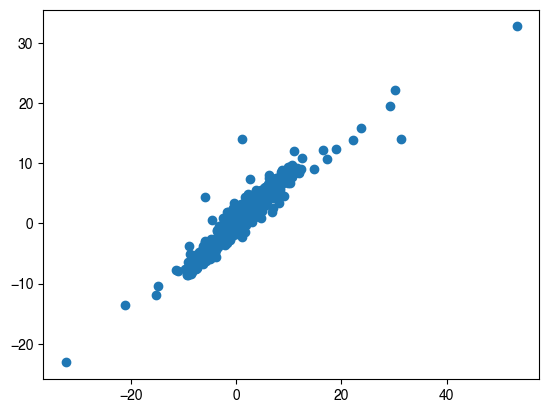

In [5]:
# plot to check the emulation performance
plt.scatter(y_clean, y_pred)

Extract the random forest directly from the trained model

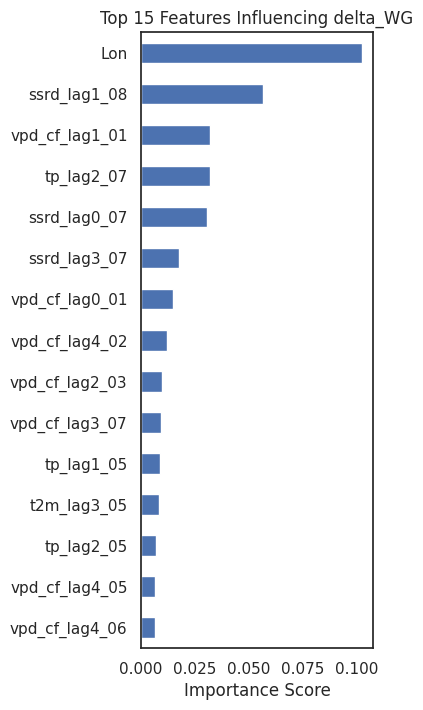

In [39]:
# 6. Extract and Visualize Feature Importance
# Create a series with importance scores mapped to feature names and sort them
importance = pd.Series(rf.feature_importances_, index=cols_to_keep).sort_values(ascending=True)

plt.figure(figsize=(3, 8))
# Display only the top 15 most influential features for clarity
importance.tail(15).plot(kind='barh') 

plt.title('Top 15 Features Influencing delta_WG')
plt.xlabel('Importance Score')
plt.show()

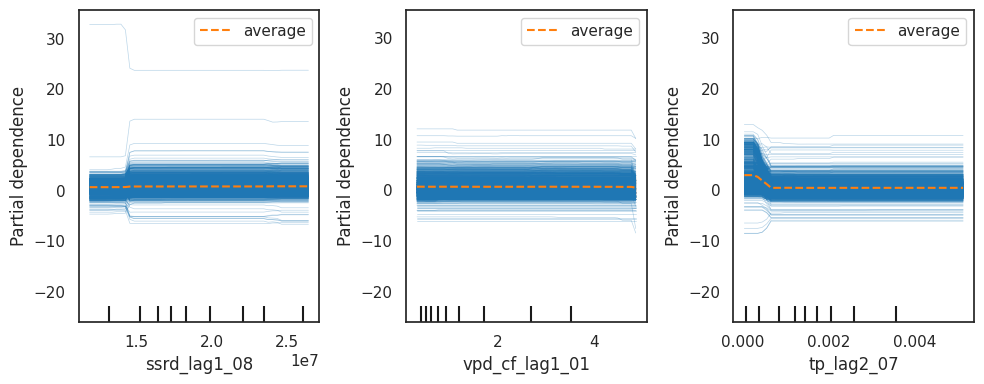

In [37]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# 7. Partial Dependence Plots (PDP) and Individual Conditional Expectation (ICE)
# These plots visualize the marginal effect of specific features on the predicted delta_WG.
# 'kind=both' displays both the average trend (PDP) and individual samples (ICE).

# Define the features to analyze based on importance or scientific interest
fig, axs = plt.subplots(1, 3, figsize=(10, 4))

# Plot for ssrd_lag1_08 (Solar Radiation lag)
display = PartialDependenceDisplay.from_estimator(
    rf,                  # The trained model
    X_clean,             # Training data
    ['ssrd_lag1_08'],    # Feature name or index to analyze
    kind='both',         # Plot both average PDP and individual ICE lines
    grid_resolution=50,  # Number of points on the feature axis
    ax=axs[0]
)

# Plot for vpd_cf_lag1_01 (Vapor Pressure Deficit lag)
display = PartialDependenceDisplay.from_estimator(
    rf, 
    X_clean, 
    ['vpd_cf_lag1_01'], 
    kind='both', 
    grid_resolution=50, 
    ax=axs[1]
)

# Plot for tp_lag2_07 (Total Precipitation lag)
display = PartialDependenceDisplay.from_estimator(
    rf, 
    X_clean, 
    ['tp_lag2_07'], 
    kind='both', 
    grid_resolution=50, 
    ax=axs[2]
)

plt.tight_layout()
plt.show()

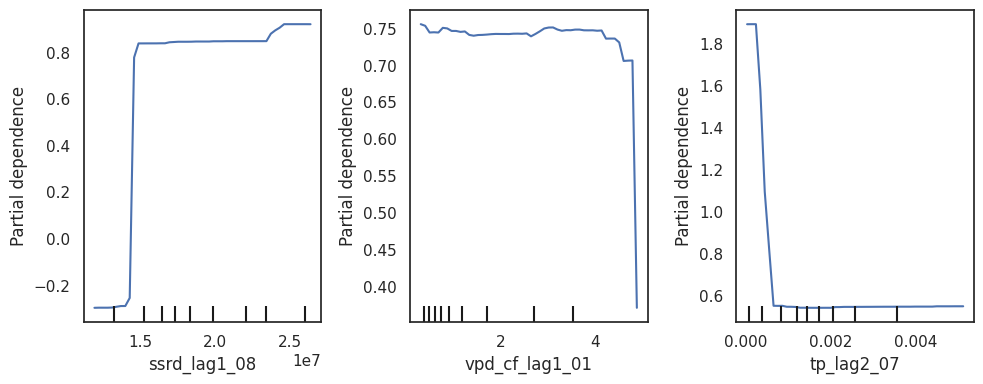

In [38]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt

# 7. Partial Dependence Plots (PDP) and Individual Conditional Expectation (ICE)
# These plots visualize the marginal effect of specific features on the predicted delta_WG.
# 'kind=both' displays both the average trend (PDP) and individual samples (ICE).

# Define the features to analyze based on importance or scientific interest
fig, axs = plt.subplots(1, 3, figsize=(10, 4))

# Plot for ssrd_lag1_08 (Solar Radiation lag)
display = PartialDependenceDisplay.from_estimator(
    rf,                  # The trained model
    X_clean,             # Training data
    ['ssrd_lag1_08'],    # Feature name or index to analyze
    kind='average',         # Plot both average PDP and individual ICE lines
    grid_resolution=50,  # Number of points on the feature axis
    ax=axs[0]
)

# Plot for vpd_cf_lag1_01 (Vapor Pressure Deficit lag)
display = PartialDependenceDisplay.from_estimator(
    rf, 
    X_clean, 
    ['vpd_cf_lag1_01'], 
    kind='average', 
    grid_resolution=50, 
    ax=axs[1]
)

# Plot for tp_lag2_07 (Total Precipitation lag)
display = PartialDependenceDisplay.from_estimator(
    rf, 
    X_clean, 
    ['tp_lag2_07'], 
    kind='average', 
    grid_resolution=50, 
    ax=axs[2]
)

plt.tight_layout()
plt.show()

In [4]:
import shap
import joblib

rf = joblib.load('rf.joblib')
# Initialize the SHAP Explainer
# TreeExplainer is optimized for tree-based models like Random Forest
explainer = shap.TreeExplainer(rf)

# Calculate SHAP values for the training dataset
# These values quantify the contribution of each feature to the specific prediction (or residual)
# shap_values = explainer.shap_values(X_clean)

In [5]:
# Use a subset for speed - 1000 samples is usually plenty for stable SHAP values
X_summary = shap.sample(X_clean, 500) 

# Fast TreeExplainer calculation
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_summary)

In [11]:
import numpy as np
np.save('shap_values.npy',shap_values)

2. Extracting More Information (Beyond the Basics)
To get the most "Hackathon-winning" insights, move beyond the Summary Plot and look for Interactions and Spatial Patterns.

A. SHAP Dependence Plots (Interaction Discovery)
This is much more powerful than a PDP because it shows how two variables interact to create an error.

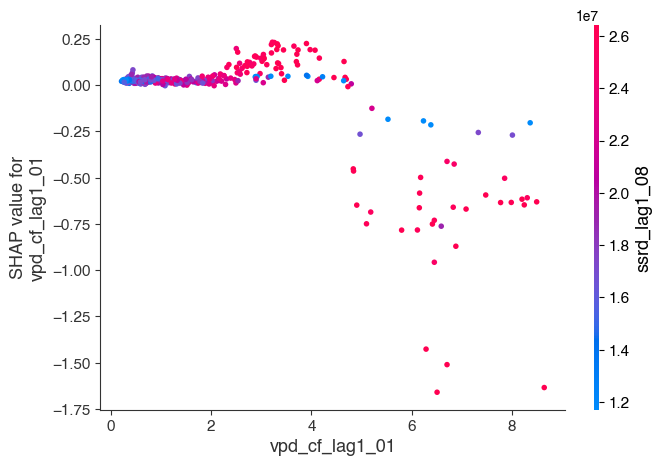

In [12]:
# Does High VPD affect the error differently when Soil Moisture is low?
shap.dependence_plot("vpd_cf_lag1_01", shap_values, X_summary, interaction_index="ssrd_lag1_08")

Scientific Insight: If the colors (e.g., Radiation levels) separate vertically, you've found a non-linear interaction that the original model likely failed to capture.

B. SHAP Heatmaps (Temporal or Cluster Patterns)
If your 8,000 rows are ordered by time or geography, use a Heatmap to see if the "Model Failure" shifts over time.

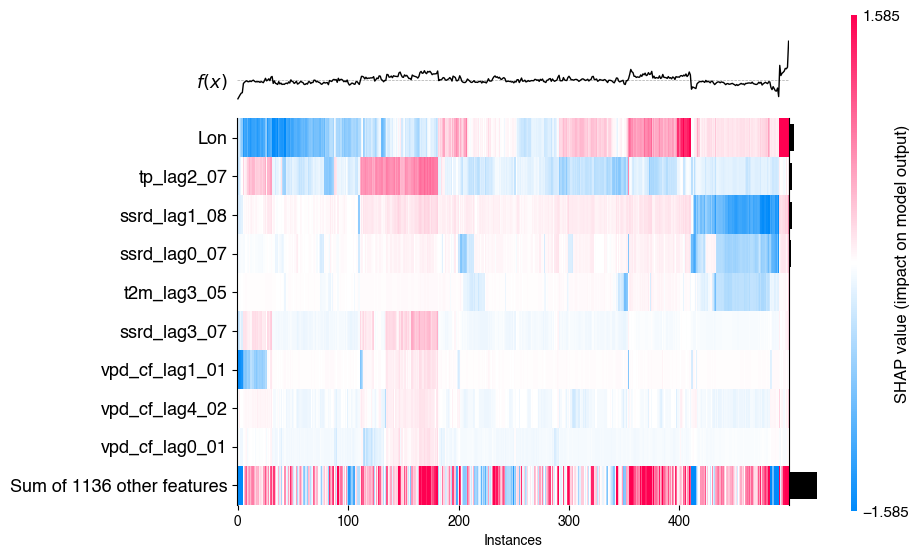

<Axes: xlabel='Instances'>

In [13]:
# Visualizes SHAP values for all samples in a heatmap format
shap.plots.heatmap(explainer(X_summary))

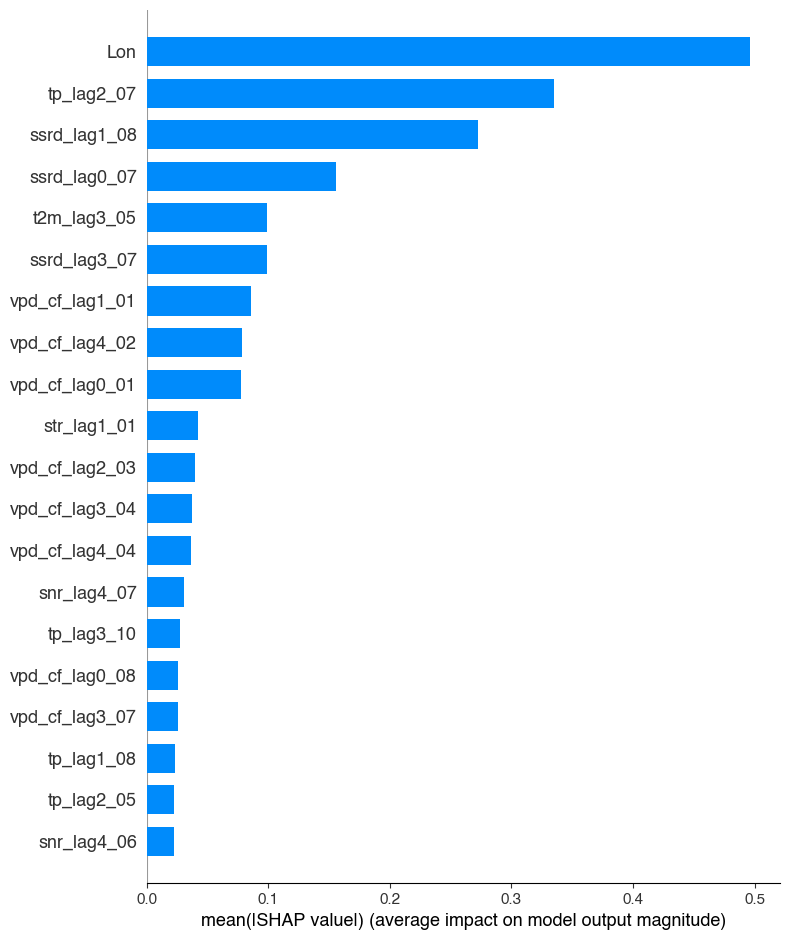

In [14]:
shap.summary_plot(shap_values, X_summary, plot_type="bar")

Generating SHAP Interaction Plots...


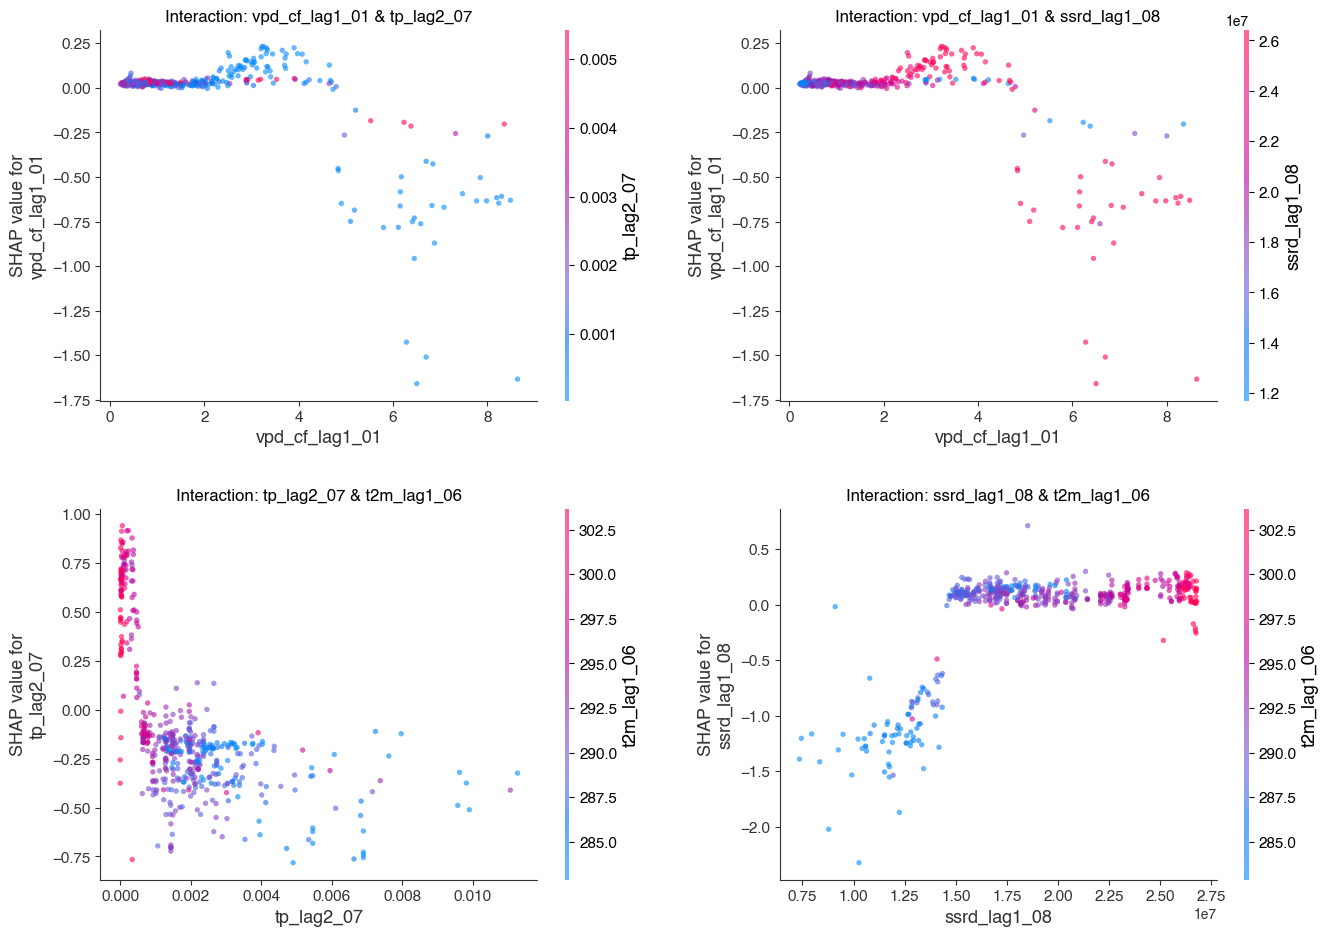

Interaction Plot Grid Complete.


In [17]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


# Update these strings with the EXACT names of your top features
interaction_pairs = [
    ("vpd_cf_lag1_01", "tp_lag2_07"),    # 1. Atmospheric Demand vs. Water Supply
    ("vpd_cf_lag1_01", "ssrd_lag1_08"),  # 2. Atmospheric Demand vs. Energy (Radiation)
    ("tp_lag2_07", "t2m_lag1_06"),      # 3. Water Supply vs. Temperature
    ("ssrd_lag1_08", "t2m_lag1_06")      # 4. Energy vs. Temperature
]

# --- Step 4: Generate the Interaction Plot Grid ---
n_pairs = len(interaction_pairs)
fig, axs = plt.subplots(int(np.ceil(n_pairs/2)), 2, figsize=(14, 10))
axs = axs.flatten() # Flatten 2D array of axes into 1D

print("Generating SHAP Interaction Plots...")

for i, (main_feat, interact_feat) in enumerate(interaction_pairs):
    if i < n_pairs:
        # Check if features exist in the dataset to avoid errors
        if main_feat in X_summary.columns and interact_feat in X_summary.columns:
            
            # The 'ax' parameter is key for creating a subplots grid
            # setting 'show=False' prevents immediate display of individual plots
            shap.dependence_plot(
                main_feat, 
                shap_values, 
                X_summary, 
                interaction_index=interact_feat,
                ax=axs[i],
                show=False,
                alpha=0.6, # Make points slightly transparent
                dot_size=15
            )
            # Add a clear title for the presentation
            axs[i].set_title(f"Interaction: {main_feat} & {interact_feat}")
        else:
            axs[i].axis('off') # Hide axis if features don't exist
            print(f"Warning: One or both features ({main_feat}, {interact_feat}) not found.")

# Remove any unused subplots
for i in range(n_pairs, len(axs)):
    fig.delaxes(axs[i])

plt.tight_layout(pad=3.0)
plt.show()

print("Interaction Plot Grid Complete.")